In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph


In [2]:
class AgentState(TypedDict):
    name:str
    age:str
    final:str

In [3]:
def first_node(state:AgentState)->AgentState:
    """"This is the first node for our sequence"""
    
    state["final"]=f"Hi {state['name']}"
    return state

def second_node(state:AgentState)->AgentState:
    """This is second node in the sequence"""
    
    state["final"]=state["final"]+f" you are {state['age']} years old"
    return state

# right now the node 1 is ok it get as we given but when it comes to 2nd node the 1 node output all changes to the 2nd node output that is years old so how to get both ans is state["final"]+2nd thing

In [4]:
g1=StateGraph(AgentState)
g1.add_node("FIRSTNODE",first_node)
g1.add_node("SECONDNODE",second_node)
g1.set_entry_point("FIRSTNODE")
# to add second node we use is g1.set_edge that is how we do it not by finish_point
g1.add_edge("FIRSTNODE" ,"SECONDNODE")
g1.set_finish_point("SECONDNODE")
app=g1.compile()

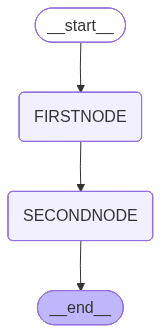

In [5]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result=app.invoke({"name":"charile", "age":20})
print(result)

{'name': 'charile', 'age': 20, 'final': 'Hi charile you are 20 years old'}


In [7]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [8]:
class AgentState(TypedDict):
    name:str
    age:str
    skills:List[str]
    final:str

In [9]:
def fn(state:AgentState)->AgentState:
    """first node of the sequence"""
    state["final"]=f"Hello {state['name']} welcome to the system"
    return state

def sn(state:AgentState)->AgentState:
    """second node in the sequence"""
    
    state["final"]=state["final"]+f"You are {state['age']} years old"
    return state

def tn(state: AgentState)->AgentState:
    """Third node in the sequence"""
    state["final"]=state["final"]+f"state['skill']"
    return state

In [10]:
g2=StateGraph(AgentState)
g2.add_node("FNN",fn)
g2.add_node("SNN",sn)
g2.add_node("TNN",tn)
g2.set_entry_point("FNN")
g2.add_edge("FNN","SNN")
g2.add_edge("SNN","TNN")
g2.set_finish_point("TNN")
ap=g2.compile()


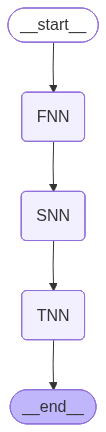

In [11]:
from IPython.display import Image,display
display(Image(ap.get_graph().draw_mermaid_png()))

In [12]:
result = ap.invoke({"name": "Linda","age": 31,"skills": ["Python", "Machine Learning", "LangGraph"]
})



In [13]:
print(result)

{'name': 'Linda', 'age': 31, 'skills': ['Python', 'Machine Learning', 'LangGraph'], 'final': "Hello Linda welcome to the systemYou are 31 years oldstate['skill']"}


In [14]:
result=ap.invoke({
    "name": "Linda",
    "age": 31,
    "skills": ["Python", "Machine Learning", "LangGraph"]
})


In [15]:
print(result)

{'name': 'Linda', 'age': 31, 'skills': ['Python', 'Machine Learning', 'LangGraph'], 'final': "Hello Linda welcome to the systemYou are 31 years oldstate['skill']"}


***Revision Sequential Graph***


In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [17]:
class AgentState(TypedDict):
    name:str
    age:str
    skill:list[str]
    final:str
    

def fnn(state:AgentState)->AgentState:
    """First node of the sequence"""
    state["final"]=f"Hello {state['name']} welcome to the system"
    return state

def snn(state:AgentState)->AgentState:
    """This is the second node"""
    state["final"]=state["final"]+f"you started at {state['age']} years old"
    return state

def Tnn(state:AgentState)->AgentState:
    """This is the third node"""
    state["final"]=state["final"]+f"state[skill]"

In [18]:
g3=StateGraph(AgentState)
g3.add_node("FNN",fnn)
g3.add_node("SNN",snn)
g3.add_node("TNN",Tnn)
g3.set_entry_point("FNN")
g3.add_edge("FNN","SNN")
g3.add_edge("SNN","TNN")
g3.set_finish_point("TNN")
apr=g3.compile()

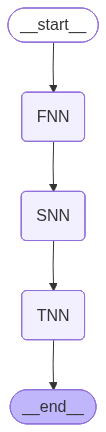

In [19]:
from IPython.display import Image,display
display(Image(apr.get_graph().draw_mermaid_png()))

In [ ]:
rs=apr.invoke({"name":"John","age":23,"skill":["PY","CPP","ML"]})

In [21]:
print(rs)

{'name': 'John', 'age': 23, 'skill': ['PY', 'CPP', 'ML'], 'final': 'Hello John welcome to the systemyou started at 23 years old'}


In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [47]:
class AgentState(TypedDict):
    name:str
    number:int
    skil:list
    final:str
   

def first(state:AgentState)->AgentState:
    """You are initial node that starts all"""
    state["final"]=f"hello {state['name']},it goos to meet you"
    return state

def second(state:AgentState)->AgentState:
    """You are the second node that does all his task corrctly"""
    state["final"]=state["final"]+f"your age is {state['number']}"
    return state
    
def third(state: AgentState)->AgentState:
    """You are the third and the last agent"""
    state["final"]=state["final"]+f"your skill are now {state['skil']}"
    return state   

In [ ]:
A1=StateGraph(AgentState)
A1.add_node("FIRST_NODE",first)
A1.add_node("SECOND_NODE",second)
A1.add_node("THIRD_NODE",third)
A1.set_entry_point("FIRST_NODE")# add_edge is used to connect 2 nodes together that is important to me 
A1.add_edge("FIRST_NODE","SECOND_NODE")
A1.add_edge("SECOND_NODE","THIRD_NODE")
A1.set_finish_point("THIRD_NODE")
ape=A1.compile()

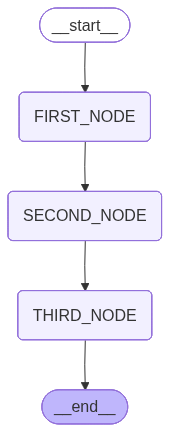

In [49]:
from IPython.display import Image,display
display(Image(ape.get_graph().draw_mermaid_png()))


In [50]:
res24=ape.invoke({
    "name":"M.Shiva kumar",
    "number":4,
    "skil":["PROGRAMMING","ML","AI ENGINEERING"]
})


In [ ]:
print(res24)

{'name': 'M.Shiva kumar', 'number': 4, 'skil': ['PROGRAMMING', 'ML', 'AI ENGINEERING'], 'final': "hello M.Shiva kumar,it goos to meet youyour age is 4your skill are now ['PROGRAMMING', 'ML', 'AI ENGINEERING']"}


: 